In [12]:

# Import the libraries we need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tell pandas to show all columns when we print a table
pd.set_option('display.max_columns', None)

print("Libraries loaded successfully!")
print("Hello, World!")

Libraries loaded successfully!
Hello, World!


In [13]:
# Load the metadata file — this is the index/summary of all battery cycles
# The path uses ".." which means "go up one folder" (from notebooks/ to the project root)
metadata = pd.read_csv("../data/cleaned_dataset/metadata.csv")

# Show the size of the table: (rows, columns)
print("Shape of metadata:", metadata.shape)

# Show the first 5 rows
metadata.head()


Shape of metadata: (7565, 10)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [14]:
# How many unique batteries are in the dataset?
print("Number of unique batteries:", metadata['battery_id'].nunique())

# Show the names of the batteries
print("Battery IDs:", metadata['battery_id'].unique())

# What types of cycles are recorded? (charge, discharge, impedance)
print("\nCycle types:")
print(metadata['type'].value_counts())

Number of unique batteries: 34
Battery IDs: <ArrowStringArray>
['B0047', 'B0045', 'B0048', 'B0046', 'B0043', 'B0032', 'B0039', 'B0040',
 'B0029', 'B0028', 'B0042', 'B0034', 'B0038', 'B0033', 'B0030', 'B0041',
 'B0027', 'B0044', 'B0036', 'B0025', 'B0026', 'B0031', 'B0049', 'B0050',
 'B0052', 'B0051', 'B0006', 'B0005', 'B0007', 'B0018', 'B0053', 'B0054',
 'B0056', 'B0055']
Length: 34, dtype: str

Cycle types:
type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64


In [15]:
# Pick one battery to focus on first
battery_to_study = 'B0005'

# Filter the metadata to only show DISCHARGE cycles for this battery
battery_data = metadata[
    (metadata['battery_id'] == battery_to_study) &
    (metadata['type'] == 'discharge')
].copy()

# Convert Capacity from text to numbers
# errors='coerce' means: if a value can't be converted, turn it into NaN (missing)
battery_data['Capacity'] = pd.to_numeric(battery_data['Capacity'], errors='coerce')

# Drop any rows where Capacity is missing
battery_data = battery_data.dropna(subset=['Capacity'])

# Add a cycle number column (1, 2, 3, ... in order)
battery_data = battery_data.reset_index(drop=True)
battery_data['cycle_number'] = battery_data.index + 1

print(f"Number of discharge cycles for {battery_to_study}: {len(battery_data)}")
print(f"Starting capacity: {battery_data['Capacity'].iloc[0]:.3f} Ah")
print(f"Final capacity:    {battery_data['Capacity'].iloc[-1]:.3f} Ah")
print(f"Capacity lost:     {(1 - battery_data['Capacity'].iloc[-1]/battery_data['Capacity'].iloc[0])*100:.1f}%")

Number of discharge cycles for B0005: 168
Starting capacity: 1.856 Ah
Final capacity:    1.325 Ah
Capacity lost:     28.6%


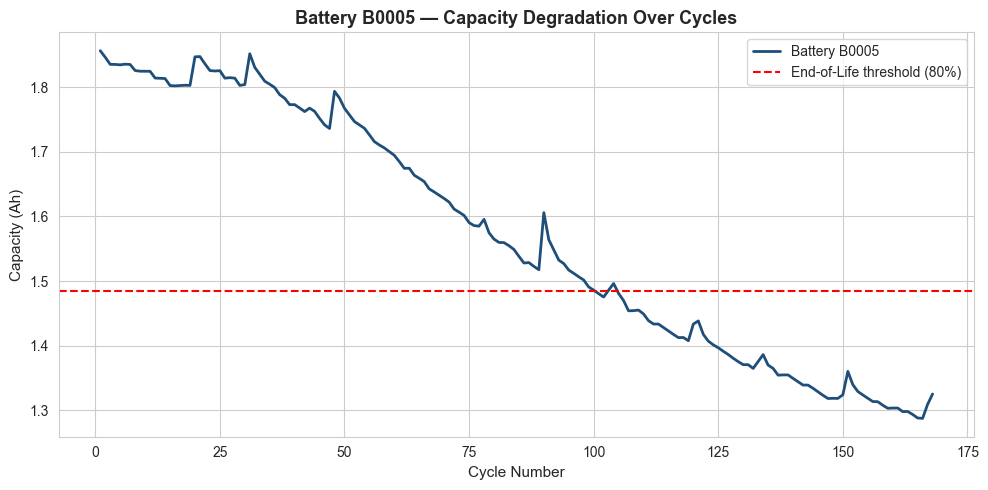

Chart saved to figures/battery_B0005_degradation.png


In [16]:
# Set the chart style to look professional
sns.set_style("whitegrid")

# Create a figure (the canvas for the chart) with a nice size
plt.figure(figsize=(10, 5))

# Plot cycle number on x-axis, capacity on y-axis
plt.plot(battery_data['cycle_number'],
         battery_data['Capacity'],
         color='#1f4e79',
         linewidth=2,
         label=f'Battery {battery_to_study}')

# Draw a horizontal red dashed line at the 80% End-of-Life threshold
eol_threshold = battery_data['Capacity'].iloc[0] * 0.80
plt.axhline(y=eol_threshold,
            color='red',
            linestyle='--',
            label='End-of-Life threshold (80%)')

# Add titles and labels
plt.title(f'Battery {battery_to_study} — Capacity Degradation Over Cycles',
          fontsize=13, fontweight='bold')
plt.xlabel('Cycle Number', fontsize=11)
plt.ylabel('Capacity (Ah)', fontsize=11)
plt.legend()

# Show the chart
plt.tight_layout()
plt.savefig('../figures/battery_B0005_degradation.png', dpi=140, bbox_inches='tight')
plt.show()

print("Chart saved to figures/battery_B0005_degradation.png")

Plotting 34 batteries...


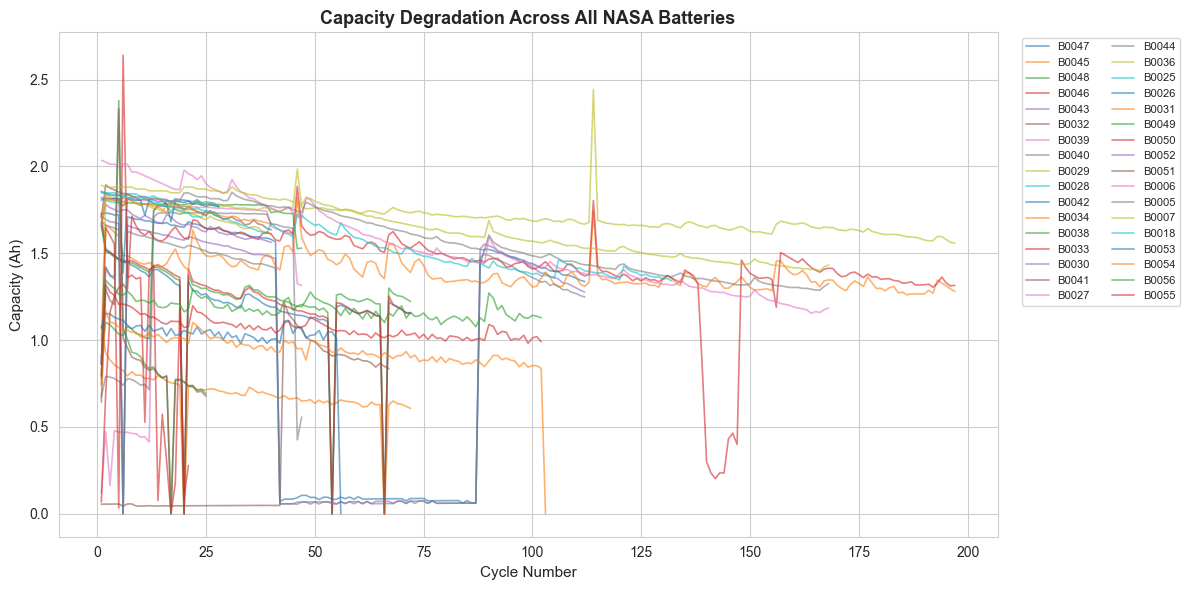


Chart saved to figures/all_batteries_degradation.png


In [17]:
# Convert Capacity to numbers for the ENTIRE metadata table (not just one battery)
metadata['Capacity'] = pd.to_numeric(metadata['Capacity'], errors='coerce')

# Keep only discharge cycles with valid capacity
all_discharge = metadata[metadata['type'] == 'discharge'].dropna(subset=['Capacity']).copy()

# For each battery, number its cycles from 1, 2, 3, ...
all_discharge['cycle_number'] = all_discharge.groupby('battery_id').cumcount() + 1

# Get the list of unique batteries
batteries = all_discharge['battery_id'].unique()
print(f"Plotting {len(batteries)} batteries...")

# Create the chart
plt.figure(figsize=(12, 6))

# Loop through each battery and plot its line
for bat_id in batteries:
    bat_data = all_discharge[all_discharge['battery_id'] == bat_id]
    plt.plot(bat_data['cycle_number'],
             bat_data['Capacity'],
             alpha=0.6,
             linewidth=1.2,
             label=bat_id)

# Titles and labels
plt.title('Capacity Degradation Across All NASA Batteries',
          fontsize=13, fontweight='bold')
plt.xlabel('Cycle Number', fontsize=11)
plt.ylabel('Capacity (Ah)', fontsize=11)

# Put the legend outside the plot since there are many batteries
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('../figures/all_batteries_degradation.png', dpi=140, bbox_inches='tight')
plt.show()

print("\nChart saved to figures/all_batteries_degradation.png")

In [18]:
# For each battery, calculate its starting capacity (cycle 1)
initial_capacities = all_discharge.groupby('battery_id')['Capacity'].first()
print("Initial capacities (first 5 batteries):")
print(initial_capacities.head())

# Now add a State-of-Health (SOH) column to the dataset
# SOH = current capacity / initial capacity × 100
all_discharge['initial_capacity'] = all_discharge['battery_id'].map(initial_capacities)
all_discharge['SOH'] = (all_discharge['Capacity'] / all_discharge['initial_capacity']) * 100

# Classify each cycle into a recycling category based on SOH
def classify_battery(soh):
    if soh >= 80:
        return 'Reuse (Second-life ready)'
    elif soh >= 60:
        return 'Repurpose (Stationary use)'
    else:
        return 'Recycle (Material recovery)'

all_discharge['recommendation'] = all_discharge['SOH'].apply(classify_battery)

# Show summary
print("\nSample of the enriched data:")
print(all_discharge[['battery_id', 'cycle_number', 'Capacity', 'SOH', 'recommendation']].head(10))

# Distribution of recommendations across the dataset
print("\nRecycling recommendations across all battery cycles:")
print(all_discharge['recommendation'].value_counts())

Initial capacities (first 5 batteries):
battery_id
B0005    1.856487
B0006    2.035338
B0007    1.891052
B0018    1.855005
B0025    1.847011
Name: Capacity, dtype: float64

Sample of the enriched data:
   battery_id  cycle_number  Capacity         SOH             recommendation
0       B0047             1  1.674305  100.000000  Reuse (Second-life ready)
4       B0047             2  1.524366   91.044729  Reuse (Second-life ready)
6       B0047             3  1.508076   90.071793  Reuse (Second-life ready)
8       B0047             4  1.483558   88.607394  Reuse (Second-life ready)
10      B0047             5  1.467139   87.626770  Reuse (Second-life ready)
12      B0047             6  1.448858   86.534913  Reuse (Second-life ready)
16      B0047             7  1.445853   86.355451  Reuse (Second-life ready)
20      B0047             8  1.431118   85.475375  Reuse (Second-life ready)
22      B0047             9  1.419275   84.767994  Reuse (Second-life ready)
24      B0047            10 

In [19]:
# Save the enriched discharge data to a CSV file in the data folder
output_path = "../data/battery_features.csv"
all_discharge.to_csv(output_path, index=False)

print(f"Saved {len(all_discharge)} rows to: {output_path}")
print(f"\nColumns saved: {list(all_discharge.columns)}")

# Confirm the file is there by re-reading it
check = pd.read_csv(output_path)
print(f"\nVerified: file contains {len(check)} rows and {len(check.columns)} columns.")

Saved 2769 rows to: ../data/battery_features.csv

Columns saved: ['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'cycle_number', 'initial_capacity', 'SOH', 'recommendation']

Verified: file contains 2769 rows and 14 columns.
